In [29]:
import torch
import torch.nn as nn

import numpy as np
import matplotlib.pyplot as plt

# import src.learning_gradient_flow.gradient_flow_optimizer as gradient_flow_optimizer
from learning_gradient_flow import gradient_flow_optimizer, adam_flow_optimizer, sindy_tools

# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device = 'cpu'
print(f"Using device: {device}")
torch.manual_seed(0)

def get_flattened_parameters(model: nn.Module) -> torch.Tensor:
    params = []
    for p in model.parameters():
        params.append(p.data.clone().view(-1))
    return torch.cat(params)

class SimpleNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(1, 8),
            nn.Tanh(),
            nn.Linear(8, 1)
        )
        # self.layers = nn.Sequential(
        #     nn.Linear(1, 16),
        #     nn.Tanh(),
        #     nn.Linear(16, 16),
        #     nn.Tanh(),
        #     nn.Linear(16, 1)
        # )
    def forward(self, x):
        return self.layers(x)

model = SimpleNet().to(device)

def true_fcn(x):
    return torch.sin(x * np.pi).to(device)

n_data = 500
nl = 0.0
x = 2 * torch.rand(n_data, 1).to(device) - 1
y = true_fcn(x) + nl * torch.randn_like(x)

# print n params
n_params = sum(p.numel() for p in model.parameters())
print(f"Number of parameters: {n_params}")

Using device: cpu
Number of parameters: 25


Epoch 1/1000, Loss: adam_torch: 0.442949, adam_custom: 0.442949, adam_ode: 0.442949, adam_ode_betas: 0.442949
Epoch 2/1000, Loss: adam_torch: 0.401132, adam_custom: 0.401132, adam_ode: 0.401132, adam_ode_betas: 0.401132
Epoch 3/1000, Loss: adam_torch: 0.366225, adam_custom: 0.366225, adam_ode: 0.366247, adam_ode_betas: 0.366242
Epoch 4/1000, Loss: adam_torch: 0.337751, adam_custom: 0.337751, adam_ode: 0.337920, adam_ode_betas: 0.337907
Epoch 5/1000, Loss: adam_torch: 0.314546, adam_custom: 0.314546, adam_ode: 0.315125, adam_ode_betas: 0.315105
Epoch 6/1000, Loss: adam_torch: 0.295465, adam_custom: 0.295466, adam_ode: 0.296652, adam_ode_betas: 0.296628
Epoch 7/1000, Loss: adam_torch: 0.279625, adam_custom: 0.279625, adam_ode: 0.281487, adam_ode_betas: 0.281464
Epoch 8/1000, Loss: adam_torch: 0.266239, adam_custom: 0.266239, adam_ode: 0.268773, adam_ode_betas: 0.268760
Epoch 9/1000, Loss: adam_torch: 0.254631, adam_custom: 0.254631, adam_ode: 0.257789, adam_ode_betas: 0.257792
Epoch 10/1

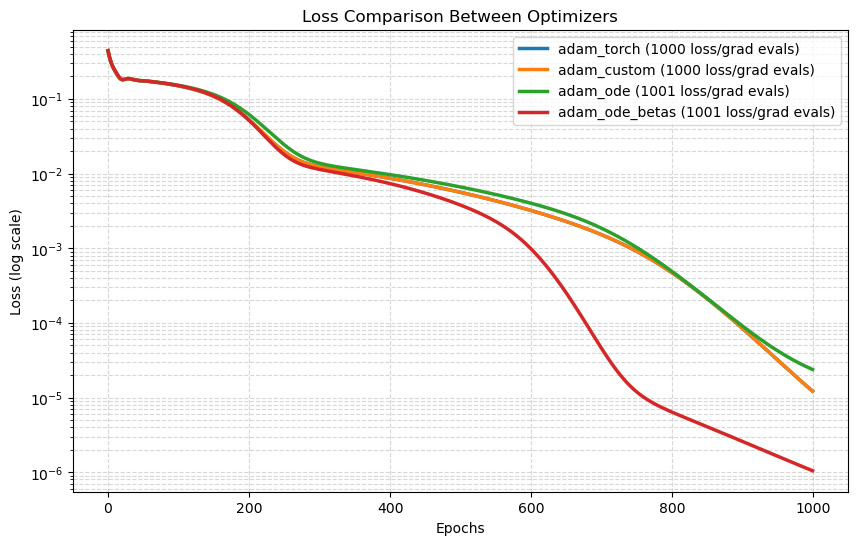

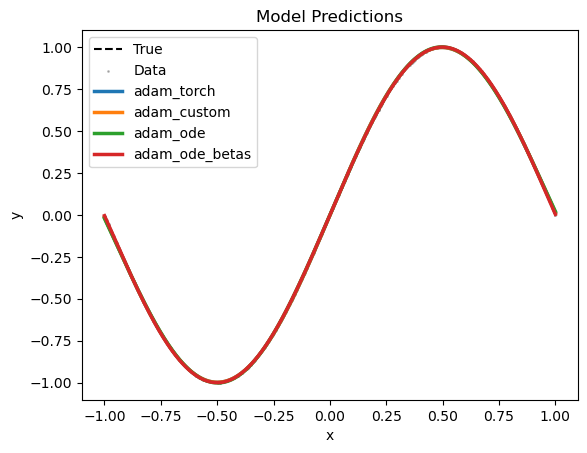

In [ ]:
# Training loop
epochs = 1000
batch_size = n_data
# batch_size = n_data // 10
# data loader
train_dataset = torch.utils.data.TensorDataset(x, y)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
n_batches = len(train_loader)

# do above, but easier
# optimizer_names = [
#                 # 'gradient_flow',
#                    'sgd01',
#                 #    'adam001',
#                    'sindy_flow',
#                    'sindy_flow_tr',
#                    'sindy_flow_weak',
#                    'sindy_flow_tr_weak',
#                 #    'sindy_flow_adam'
#                    ]
optimizer_names = [
                    'adam_torch',
                    'adam_custom',
                    'adam_ode',
                    'adam_ode_betas'
                  ]
optimizers = {}
for opt_name in optimizer_names:
    optimizers[opt_name] = {
        'model': SimpleNet().to(device),
        'optimizer': None,
        'losses': [],
        'param_history': []
    }

# history_size = 100
# retrain_interval = 148
history_size = 100
retrain_interval = 200

betas = (0.9, 0.999)
betas_cont = (0.9, 0.995)

lr = 0.01
same_time = False

solver_fn = sindy_tools.dense_solver
solver_params = None
# solver_fn = sindy_tools.stls_sparse_solver
# solver_params = sindy_tools.SparseSolverParams(threshold=0.0, normalize_columns=False)
sindy_params = sindy_tools.SINDyParams(poly_order=1, include_bias=True,
                                       solver_fn=solver_fn, solver_params=solver_params)
# sindy_params = sindy_tools.SINDyParams(poly_order=4, include_bias=True)

optimizers['adam_torch']['optimizer'] = torch.optim.Adam(
    optimizers['adam_torch']['model'].parameters(), lr=lr, betas=betas)
optimizers['adam_custom']['optimizer'] = adam_flow_optimizer.CustomAdam(
    optimizers['adam_custom']['model'].parameters(), lr=lr, betas=betas)
optimizers['adam_ode']['optimizer'] = adam_flow_optimizer.AdamEuler(
    optimizers['adam_ode']['model'].parameters(), lr=lr, betas=betas)
optimizers['adam_ode_betas']['optimizer'] = adam_flow_optimizer.AdamEuler(
    optimizers['adam_ode_betas']['model'].parameters(), lr=lr, betas=betas_cont)


# ensure all start at the same parameters (just use the first model)
for opt_name, opt_data in optimizers.items():
    name0 = optimizer_names[0]
    if opt_name != name0:
        opt_data['model'].load_state_dict(optimizers[name0]['model'].state_dict())
    # if opt_name != 'gradient_flow':
    #     opt_data['model'].load_state_dict(optimizers['gradient_flow']['model'].state_dict())
    opt_data['param_history'].append(get_flattened_parameters(opt_data['model']))


def create_closure(model, optimizer):
    def closure():
        x_batch, y_batch = next(iter(train_loader))  # Get a batch of data
        optimizer.zero_grad()
        output = model(x_batch)  # Uses global x, y data
        loss = torch.mean((output - y_batch)**2)
        loss.backward()
        return loss
    return closure

for epoch in range(epochs):
    # Train each optimizer for one step
    for opt_name, opt_data in optimizers.items():
        loss = 0.0
        model = opt_data['model']
        optimizer = opt_data['optimizer']

        # Create closure for this model/optimizer
        for x_batch, y_batch in train_loader:
            closure_fn = create_closure(model, optimizer)
            if 'adam_ode' in opt_name:
                loss = loss + optimizer.step(closure_fn, same_time=same_time).item()
            else:
                loss = loss + optimizer.step(closure_fn).item()

        # Store results
        opt_data['losses'].append(loss)
        opt_data['param_history'].append(get_flattened_parameters(model))

    # Print progress
    if epoch < 20 or epoch % (epochs // 20) == 0 or epoch == epochs - 1:
        status = ", ".join([f"{name}: {data['losses'][-1]:.6f}" for name, data in optimizers.items()])
        print(f"Epoch {epoch+1}/{epochs}, Loss: {status}")


for opt_name, opt_data in optimizers.items():
    # get number of evals, and record them. We will put them in legend
    if hasattr(opt_data['optimizer'], 'state'):
        func_evals = opt_data['optimizer'].state.get('func_evals', None)
        if func_evals is not None:
            opt_data['func_evals'] = func_evals
        else:
            opt_data['func_evals'] = epochs*n_batches
    else:
        opt_data['func_evals'] = epochs*n_batches

colors = [f'C{i%4}' for i in range(len(optimizers))]
linestyles = ['-']*4 + [':']*4

# Plot loss curves
plt.figure(figsize=(10, 6))
lw_factor = 2.5
for i, (opt_name, opt_data) in enumerate(optimizers.items()):
    label = f'{opt_name} ({opt_data["func_evals"]} loss/grad evals)'
    plt.semilogy(opt_data['losses'], label=label, linewidth=lw_factor,
                 color=colors[i], linestyle=linestyles[i])
    # lw_factor *= 0.75
plt.xlabel('Epochs')
plt.ylabel('Loss (log scale)')
plt.title('Loss Comparison Between Optimizers')
plt.legend()
plt.grid(True, which='both', linestyle='--', alpha=0.5)
# save fig
plt.savefig(
    f'figs/learned_adam_ode_lr{lr}_same_time_{same_time}_hs_rt_{history_size}_{retrain_interval}_loss.png',
    dpi=300, bbox_inches='tight')

# compare on data
x_eval = torch.linspace(-1, 1, 1000).view(-1, 1).to(device)
y_eval = true_fcn(x_eval).to(device)
y_eval_preds = {}
for opt_name, opt_data in optimizers.items():
    with torch.no_grad():
        y_eval_preds[opt_name] = opt_data['model'](x_eval)
plt.figure()
lw_factor = 2.5
plt.plot(x_eval.cpu(), y_eval.cpu(), 'k--', label='True')
plt.scatter(x.cpu(), y.cpu(), color='gray', alpha=0.5, label='Data', s=1)
for i, (opt_name, y_eval_pred) in enumerate(y_eval_preds.items()):
    plt.plot(x_eval.cpu(), y_eval_pred.cpu(), label=opt_name, linewidth=lw_factor,
             color=colors[i], linestyle=linestyles[i])
    # lw_factor *= 0.75
plt.title('Model Predictions')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()

plt.savefig(
    f'figs/adam_ode/adam_ode_lr{lr}_betas_{betas}_{betas_cont}_prediction.png',
    dpi=300, bbox_inches='tight')